# N7 · Card vs Cash — cannibalisation or halo?

**Panel question** — asked by the **Head of Product** and the **CRO**
together: *"Design the pricing approach for the prepaid multi-currency card
vs cash — is the card cannibalising cash or growing the pie?"*

Three traps, all priced here:
1. Reporting **gross uplift** instead of cannibalisation-adjusted
   incrementality.
2. Forgetting that a price cut costs margin on the **whole existing base**,
   not just the marginal customer.
3. Using today's world as the baseline when the real counterfactual is the
   **decline** — Wise/Revolut keep taking travellers.

**Contract:** known choice model (multinomial logit, known preferences) →
gross uplift flatters → base-margin cost makes the blanket cut ~flat →
in the fintech-attack world the blanket cut still loses but the **targeted**
cut wins → the test that measures it.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(17)

# --- Ground truth: two segments choosing {cash, card, fintech} ---------------
# utility = base preference - sensitivity x total price (% of load)
SEGMENTS = {
    #                share  a_cash a_card a_fintech  b (per pp)
    "cash_preference": (0.60, 2.2,   0.8,   -0.8,     0.45),
    "digital_open":    (0.40, 0.6,   1.1,    0.9,     0.85),
}
PRICE = {"cash": 4.3, "card": 3.2, "fintech": 0.6}       # % of load

def contrib_card(p):
    """£ contribution per £100 load. Card LTV includes in-life FX, reloads,
    breakage — and passes ~85% of any price cut straight to the bottom line."""
    return 3.60 - 0.85 * (3.2 - p)

CONTRIB_CASH = 2.60

def shares(price, seg_over=None, seg_price=None):
    """Multinomial-logit shares by segment (optionally segment-specific card
    price = a TARGETED offer) -> per-segment and blended shares + portfolio £."""
    out, port = {}, 0.0
    for seg, (w, ac, ak, af, b) in SEGMENTS.items():
        a = {"cash": ac, "card": ak, "fintech": af}
        if seg_over and seg in seg_over:
            a.update(seg_over[seg])
        p = dict(price)
        if seg_price and seg in seg_price:
            p["card"] = seg_price[seg]
        v = {k: a[k] - b * p[k] for k in a}
        ex = {k: np.exp(v[k]) for k in v}
        tot = sum(ex.values())
        out[seg] = {k: ex[k] / tot for k in ex}
        port += w * (out[seg]["cash"] * CONTRIB_CASH
                     + out[seg]["card"] * contrib_card(p["card"]))
    blend = {k: sum(SEGMENTS[s][0] * out[s][k] for s in out) for k in PRICE}
    return out, blend, port

_, base, port_base = shares(PRICE)
print("Baseline blended shares:", {k: f"{v:.1%}" for k, v in base.items()})
print(f"Portfolio contribution: £{port_base:.3f} per £100 of traveller demand")

Baseline blended shares: {'cash': '37.1%', 'card': '19.2%', 'fintech': '43.8%'}
Portfolio contribution: £1.653 per £100 of traveller demand


## 1. Cut the card price — the gross-uplift illusion

Card total cost 3.2% → 2.4%, for everyone. The product slide says
"+40% card volume — success". Two things the slide doesn't show: where the
volume came from, and what the cut cost on the base.

In [2]:
p_cut = PRICE | {"card": 2.4}
_, cut, port_cut = shares(p_cut)

gross_uplift = cut["card"] / base["card"] - 1
d = {k: cut[k] - base[k] for k in base}
cannib_share = -d["cash"] / d["card"]

print(f"Card share: {base['card']:.1%} -> {cut['card']:.1%}  "
      f"(gross uplift +{gross_uplift:.0%} — the slide number)")
print(f"Where it came from: cash {d['cash']:+.2%}, fintech {d['fintech']:+.2%}")
print(f"-> {cannib_share:.0%} of the card gain is CANNIBALISED cash; "
      f"only {1 - cannib_share:.0%} is won from the fintechs")
print(f"\nAnd the cut costs {0.85 * 0.8:.2f}£/£100 of margin on every EXISTING "
      "card customer.")
print(f"Portfolio contribution: £{port_base:.3f} -> £{port_cut:.3f} per £100 "
      f"({port_cut/port_base - 1:+.1%})  <- the honest number: roughly FLAT")

Card share: 19.2% -> 27.0%  (gross uplift +41% — the slide number)
Where it came from: cash -3.53%, fintech -4.35%
-> 45% of the card gain is CANNIBALISED cash; only 55% is won from the fintechs

And the cut costs 0.68£/£100 of margin on every EXISTING card customer.
Portfolio contribution: £1.653 -> £1.662 per £100 (+0.5%)  <- the honest number: roughly FLAT


## 2. The fintech-attack world: blanket cut loses, targeted cut wins

Wise turns the screws on the digital-open segment (stronger pull, 0.4%
pricing). Three responses, priced against the **declining** counterfactual:
do nothing, cut the card for everyone, or cut it **only for the at-risk
segment** (an in-app retention offer, not a rate-card change).

                    world  portfolio  vs its baseline
         today, no change      1.653            0.000
       today, blanket cut      1.662            0.008
   Wise attack, no change      1.505            0.000
 Wise attack, blanket cut      1.476           -0.028
Wise attack, TARGETED cut      1.535            0.030

Blanket cut in the attack world: -0.028 (margin bleed on the loyal base outweighs retention)
Targeted cut in the attack world: +0.030 (defends exactly where the attack lands — and nowhere else)


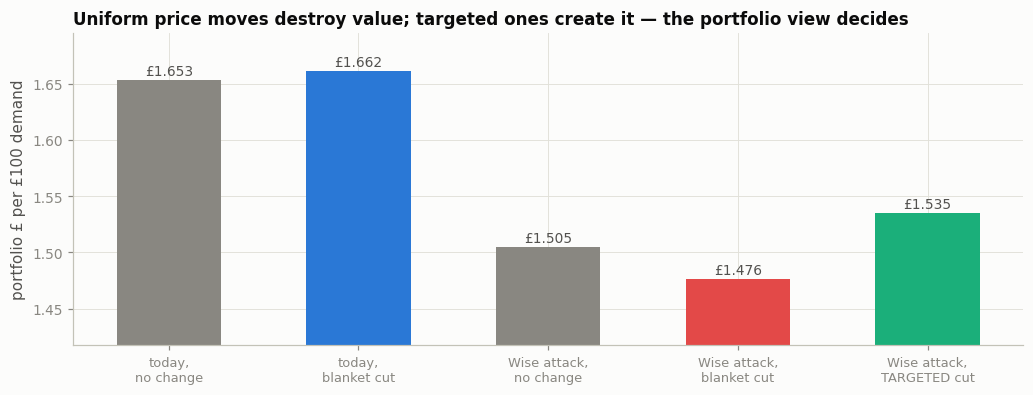

In [3]:
aggressive = {"digital_open": {"fintech": 1.9}}
p_agg = PRICE | {"fintech": 0.4}

_, s_none, port_none = shares(p_agg, seg_over=aggressive)
_, s_blkt, port_blkt = shares(p_agg | {"card": 2.4}, seg_over=aggressive)
_, s_targ, port_targ = shares(p_agg, seg_over=aggressive,
                              seg_price={"digital_open": 2.4})

rows = pd.DataFrame({
    "world": ["today, no change", "today, blanket cut",
              "Wise attack, no change", "Wise attack, blanket cut",
              "Wise attack, TARGETED cut"],
    "portfolio": [port_base, port_cut, port_none, port_blkt, port_targ],
})
rows["vs its baseline"] = rows.portfolio - [port_base, port_base,
                                            port_none, port_none, port_none]
print(rows.round(3).to_string(index=False))
print(f"\nBlanket cut in the attack world: {port_blkt - port_none:+.3f} "
      "(margin bleed on the loyal base outweighs retention)")
print(f"Targeted cut in the attack world: {port_targ - port_none:+.3f} "
      "(defends exactly where the attack lands — and nowhere else)")

fig, ax = plt.subplots(figsize=(9.5, 3.7))
x = np.arange(len(rows))
cols = [C["muted"], C["blue"], C["muted"], C["red"], C["aqua"]]
ax.bar(x, rows.portfolio, 0.55, color=cols)
for i, v in enumerate(rows.portfolio):
    ax.annotate(f"£{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 3),
                ha="center", fontsize=9, color=C["ink2"])
ax.set_xticks(x)
ax.set_xticklabels([w.replace(", ", ",\n") for w in rows.world], fontsize=8.5)
ax.set_ylabel("portfolio £ per £100 demand")
ax.set_ylim(rows.portfolio.min() * 0.96, rows.portfolio.max() * 1.02)
ax.set_title("Uniform price moves destroy value; targeted ones create it — "
             "the portfolio view decides")
plt.tight_layout(); plt.show()

This is the same lesson the case-study engine teaches at channel level
(`aop_scenario.py`: a blanket +10% margin *reduces* contribution while
targeted harvesting raises it) — here it reappears at **product × segment**
level. Uniform moves are almost never the answer.

## 3. The test that actually measures this

* Randomise the card offer at **geo-cluster level** (N1's design — card and
  cash cross-shop exactly like branches do).
* Record **both** card *and* cash volumes per cell — the outcome is
  **portfolio contribution per cell**, never card volume alone.
* Run long enough to capture **reload and in-life behaviour** — a 2-week
  read structurally flatters cannibalisation because the card's value
  arrives later.
* Report cannibalisation-adjusted incrementality with a holdout, and show
  the fintech-defence counterfactual as its own line, not blended away.

Product hook worth naming in the room: order-size tiers already let cash +
card **combine** to a better rate — price the bundle, not the SKU.

## The 60-second answer

> "I'd refuse to answer it with gross uplift. In this choice model a blanket
> card price cut lifts card share by about forty percent — the slide looks
> great — but nearly half of that gain is cannibalised cash, and the cut
> costs margin on every existing cardholder, so the portfolio impact is
> roughly flat. The honest metric is cannibalisation-adjusted
> incrementality at portfolio contribution, measured in a cluster-randomised
> test where every cell records both card and cash volumes.
>
> The counterfactual matters even more. Against the world where Wise is
> actively pulling the digital-open segment, doing nothing means decline —
> but the blanket cut *still* loses, because the margin bleed on the loyal
> base outweighs the retention. What wins is the targeted version: a
> retention offer to the at-risk segment only, which defends exactly where
> the attack lands. It's the same lesson as channel pricing — uniform moves
> destroy value, targeted ones create it — and I'd put both counterfactuals
> in front of the committee, with the caveat that segment-targeted pricing
> needs a fair-value check before it ships."

### What I'd say if pushed deeper

1. **"Isn't a targeted discount to digital customers a Consumer Duty
   problem in reverse?"** — It's the right challenge: the at-risk segment is
   the *less* vulnerable one, so targeting them widens the differential N6
   flagged. I'd pair the retention offer with the assisted-channel
   mitigations, and document both in the same fair-value assessment.
2. **"How would you validate the choice model?"** — Revealed substitution:
   past card-fee changes and cash stockout episodes (N3) give natural
   cross-elasticity reads; the cluster test calibrates it properly, and the
   logit is then the scenario engine between tests.
3. **Honest limitation.** Logit's IIA property forces proportional
   substitution — it understates how close cash and card are for the
   cash-preference segment. A nested logit (cash + card in an 'our brand'
   nest) is the next model up; the test data would pin the nesting
   parameter.